### This notebook compute "VSB8. Degradation index of priority ecosystems" indicator for the 27 basins of IKI Project

**Created:** 10/10/2025 by Serena Gilson (sgilson@rti.org)  
**Project #:** 0219481  
**Last modified:**
**Status:** 
**QA Status:** reviewed by  
**Original Script Stored at:** Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Vulnerabilidad 
 
**Inputs:**   Shapefile of COMIDs and districts, Mapa de Areas degradadas (MINAM), Mapa Nacional de ecosistemas (MINAM), Mapa prioritario de resturacion (SERFOR)

**Outputs:** 
 
**Assumptions:** 
 
**Future work:** 
 
**Notes:** Awaiting input data (mapa priortorio de restuaracion de SERFOR). 

In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt

In [ ]:
#SETTINGS

#user = 'jmayo'
#user= 'cpickering'
user = 'sgilson'
ScnID= 1 #Scenario ID -- 1: Baseline, 1981-2005, 2: Future, 2030, 3: Future: 2050
IndID= 308 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
db_path = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db'


In [ ]:
#INDICATOR INPUT DATA

#Read in subbasin shapefile with districts
subbasins_shapefile = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/Peru_AHD_with_districts.shp'
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')


#AWAITING Mapa prioritario de resturacion de SERFOR
#Mapa de Areas degradadas (MINAM): "C:\Users\sgilson\Research Triangle Institute\IKI Peru Project - General\Interno\GIS\2_USO_DE_SUELO_GEOLOGIA_LAND_USE_COVER\Cobertura_Vegetal\degradacion2022\ad2022_final.tif" https://geoservidor.minam.gob.pe/recursos/intercambio-de-datos/
#Mapa Nacional de ecosistemas (MINAM): C:\Users\sgilson\Research Triangle Institute\IKI Peru Project - General\Interno\GIS\2_USO_DE_SUELO_GEOLOGIA_LAND_USE_COVER\Cobertura_Vegetal\MAPA-NACIONAL-DE-ECOSISTEMAS\MAPA_NACIONAL_DE_ECOSISTEMAS_20-12-2018.shp

SQLITE INSERT 

In [ ]:
#Update relevant dataframe and value column from the calculations above for the specific indicator
insert_data= subbasins_gdf #COMID and Feauture_Count
value_column= 'Feature_Count'

In [ ]:
# Connect to your SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Fixed IndID and ScnID (update above)

#For now I am commenting out the looping of scenarios as I imagine we might run just baseline scenarios for now.
# Define the mapping between scenario and DataFrame column
# scenario_columns = {
#     1: 'ACTUAL ANUAL',
#     2: '2030 ANUAL',
#     3: '2050 ANUAL'
# }

# Prepare list of rows to insert
rows_to_insert = []

#for scn_id, column_name in scenario_columns.items():
for _, row in insert_data.iterrows():
    comid = row['COMID']
    value = row[value_column]
    #normalized_value = None  # or compute something like: value / max_value #took out normalized value from the table for now
    rows_to_insert.append((ScnID, IndID, comid, value))

# Insert data into IndValues_Dyn
insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""


In [21]:
# Check for duplicates in the input dataframe before insert
df_check = pd.DataFrame(rows_to_insert, columns=['ScnID', 'IndID', 'COMID', 'Value'])
duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])
print("Duplicates in rows_to_insert:", df_check[duplicates])

Duplicates in rows_to_insert: Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [ ]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()

#TEST FOR JUST ONE COMID TO ENSURE METHOD

C:\Users\sgilson\AppData\Local\Temp\ipykernel_39204\3821138212.py:23: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  infra_within_basin.plot(ax=ax, markersize=10, label=label)
C:\Users\sgilson\AppData\Local\Temp\ipykernel_39204\3821138212.py:23: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  infra_within_basin.plot(ax=ax, markersize=10, label=label)
C:\Users\sgilson\AppData\Local\Temp\ipykernel_39204\3821138212.py:23: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  infra_within_basin.plot(ax=ax, markersize=10, label=label)
C:\Users\sgilson\AppData\Local\Temp\ipykernel_39204\3821138212.py:23: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  infra_within_basin.plot(ax=ax, markersize=10, label=label)
C:\Users\sgilson\AppData\Local\Temp\ipykernel_39204\3821138212.py:23: UserWarning: The GeoDataFr

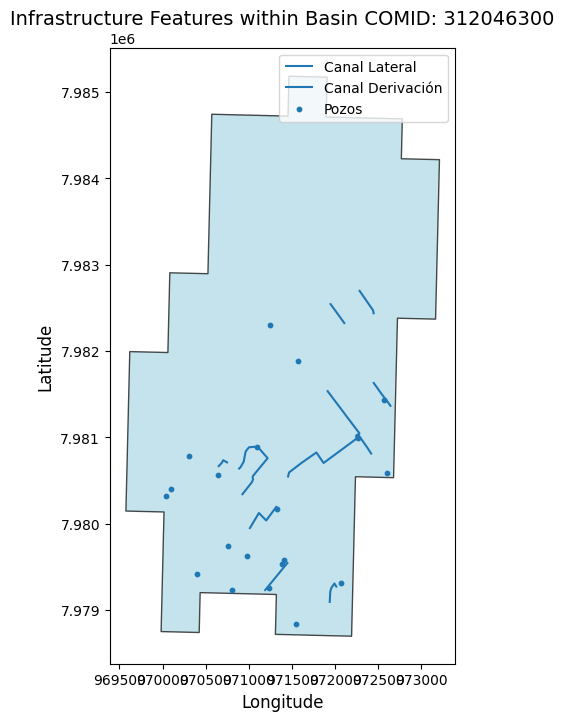

In [ ]:
import matplotlib.pyplot as plt

# Specify the COMID to plot
target_comid = 312046300  # Replace with the desired COMID

# Filter the subbasin for the target COMID
target_basin = subbasins_gdf[subbasins_gdf['COMID'] == target_comid]

# Initialize a plot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the target subbasin
target_basin.plot(ax=ax, color='lightblue', edgecolor='black', alpha=0.7, label=f'Basin COMID: {target_comid}')

# Plot infrastructure features within the target subbasin
for infra_gdf, label in zip(infrastructure_gdfs, [
    'Bocatomas', 'Canal Trasvase', 'Canal Lateral', 'Canal Aducción', 
    'Canal Derivación', 'Embalses', 'Pozos', 'Presas', 'Acueductos'
]):
    infra_within_basin = infra_gdf[infra_gdf.geometry.within(target_basin.geometry.iloc[0])]
    infra_within_basin.plot(ax=ax, markersize=10, label=label)

# Add title, legend, and labels
plt.title(f'Infrastructure Features within Basin COMID: {target_comid}', fontsize=14)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.legend()

# Show the plot
plt.show()